In [1]:
import os
import torch
import pandas as pd
import scanpy as sc
from SPHERE.preprocess import *
from SPHERE.SPHERE import *
from SPHERE.utils import *
import numpy as np
device = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
random_seed = 2022
fix_seed(random_seed)

## Cerebellum

In [ ]:
datasets = ['./E11.h5ad',
            './E135.h5ad',
            './E185.h5ad',]
adata_list = [sc.read_h5ad(dataset) if isinstance(dataset, str) else dataset for dataset in datasets]
slice_name_list = ['E11_0-S1', 'E13_5-S1', 'E18_5-S1']

import anndata as ad
adata = ad.concat(adata_list, label="slice_name", keys=slice_name_list)
print(adata)

AnnData object with n_obs × n_vars = 119119 × 17400
    obs: 'slice_name'
    uns: 'adj_spatial_sparse'
    obsm: 'X_lsi', 'adj_combined', 'adj_feature', 'feat', 'spatial'


/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
adata.X[adata.X.nonzero()] = 1
lsi_scale(adata, n_components=201) 
adata.obsm['feat'] = adata.obsm['X_lsi'].copy()

In [ ]:
adata = construct_neighbor_graph_inte_scale(adata, slice_name_list)

In [3]:
batch_categories = np.unique(adata.obs['slice_name'])
batch_to_index = {batch: idx for idx, batch in enumerate(batch_categories)}
batch_indices = adata.obs['slice_name'].map(batch_to_index).values
num_batches = len(batch_categories)
batch_labels = np.eye(num_batches)[batch_indices]

In [ ]:
model_ref = SPHERE(adata, device=device, learning_rate=0.001, epochs=30, dim_hid=64, dim_input=100,
               integrate=True, batch_label=batch_labels,slice_name_list = slice_name_list, lambda_fea_recon=1,lambda_spa_recon=0.,
               lambda_recon=20,lambda_con=12,lambda_align=20,lambda_latent=30,scale=True,pretrain=False)


/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [6]:
output_3 = model_ref.train_inte_scale(batch_size=2048)
ref_weight_path = './ref_model_3.pth'
os.makedirs(os.path.dirname(ref_weight_path), exist_ok=True)
torch.save(model_ref.model.state_dict(), ref_weight_path)

adata_final = adata.copy()
adata_final.obsm['latent'] = output_3['latent']
adata_final.obsm['latent'] = pca(adata_final, use_reps='latent', n_comps=20)

sc.pp.neighbors(adata_final, use_rep='latent', n_neighbors=30)
sc.tl.umap(adata_final)



Epoch 30/30: 100%|██████████| 58/58 [00:05<00:00, 10.22it/s, loss=25.8339]
/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from sklearn.mixture import GaussianMixture
import scanpy as sc
import pandas as pd
gm = GaussianMixture(n_components=12, covariance_type='tied', random_state=1234)
y = gm.fit_predict(adata_final.obsm['latent'], y=None)
adata_final.obs["leiden"] = pd.Series(y, index=adata_final.obs.index, dtype='category')


In [ ]:
datasets = ['./E11.h5ad',
            './E135.h5ad',
            './E155.h5ad',
            './E185.h5ad',]
adata_list = [sc.read_h5ad(dataset) if isinstance(dataset, str) else dataset for dataset in datasets]
slice_name_all = ['E11_0-S1', 'E13_5-S1', 'E15_5-S1', 'E18_5-S1']

import anndata as ad
adata_4 = ad.concat(adata_list, label="slice_name", keys=slice_name_all)

adata_4.X[adata_4.X.nonzero()] = 1
lsi_scale(adata_4, n_components=201) 
adata_4.obsm['feat'] = adata_4.obsm['X_lsi'].copy()
adata_4 = construct_neighbor_graph_inte_scale(adata_4, slice_name_all)

In [3]:
batch_categories_4 = np.unique(adata_4.obs['slice_name'])
batch_indices_4 = adata_4.obs['slice_name'].map({batch: idx for idx, batch in enumerate(batch_categories_4)}).values
batch_labels_4 = np.eye(len(batch_categories_4))[batch_indices_4]

In [ ]:
model_query = SPHERE(adata_4, device=device, learning_rate=0.001, epochs=30, dim_hid=64, dim_input=100,
               integrate=True, batch_label=batch_labels_4,slice_name_list = slice_name_all, lambda_fea_recon=0,lambda_spa_recon=1,
               lambda_recon=20,lambda_con=12,lambda_align=25,lambda_latent=40,scale=True,pretrain=False)

/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/anndata/_core/anndata.py:1838: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [ ]:
model_query.model = AttnAE_scale(
    model_query.dim_input, model_query.dim_hid, model_query.dim_output, 
    model_query.device, dropout=0.1, add_act=True, inte=True, scale=True
).to(device)
model_query.model.load_state_dict(torch.load(ref_weight_path), strict=False)

print("\n🚀 Executing reference-locked query projection loop...")
output_4 = model_query.train_query_frozen(batch_size=2048, query_epochs=50)


🚀 Executing reference-locked query projection loop...
🔒 Architecture Lock active. Mapping query seamlessly...


Query Epoch 1/50: 93it [00:03, 27.06it/s, loss=45.1307]                        
Query Epoch 2/50: 93it [00:03, 27.74it/s, loss=45.0700]                        
Query Epoch 3/50: 93it [00:03, 27.87it/s, loss=44.9217]                        
Query Epoch 4/50: 93it [00:03, 28.02it/s, loss=44.4462]                        
Query Epoch 5/50: 93it [00:03, 27.28it/s, loss=44.9482]                        
Query Epoch 6/50: 93it [00:03, 28.33it/s, loss=44.4728]                        
Query Epoch 7/50: 93it [00:03, 28.33it/s, loss=44.2376]                        
Query Epoch 8/50: 93it [00:03, 28.26it/s, loss=43.1202]                        
Query Epoch 9/50: 93it [00:03, 27.49it/s, loss=42.9964]                        
Query Epoch 10/50: 93it [00:03, 28.21it/s, loss=42.9300]                        
Query Epoch 11/50: 93it [00:03, 28.28it/s, loss=42.0637]                        
Query Epoch 12/50: 93it [00:03, 27.83it/s, loss=41.6905]                        
Query Epoch 13/50: 93it [00:03, 25.97

In [ ]:
adata_query_all = adata_4.copy()
adata_query_all.obsm['latent'] = output_4['latent']
adata_query_all.obsm['latent'] = pca(adata_query_all, use_reps='latent', n_comps=20)
adata_only_query = adata_query_all[adata_query_all.obs['slice_name'] == 'E15_5-S1'].copy()

print("🧬 Computing independent graph neighbors for E15_5 to anchor spatial partitions...")
sc.pp.neighbors(adata_only_query, use_rep='latent', n_neighbors=30)

from sklearn.mixture import GaussianMixture
import scanpy as sc
import pandas as pd
gm = GaussianMixture(n_components=12, covariance_type='tied', random_state=1234)
y = gm.fit_predict(adata_only_query.obsm['latent'], y=None)
adata_only_query.obs["leiden"] = pd.Series(y, index=adata_only_query.obs.index, dtype='category')


In [ ]:
adata_ref_true = adata_final.copy()

print("⚡ Building flow-field mapping projector from frozen Reference standard...")
ref_latent = adata_ref_true.obsm['latent']
ref_umap = adata_ref_true.obsm['X_umap']

import umap
projector = umap.UMAP(n_neighbors=30, min_dist=0.5, random_state=2022).fit(ref_latent)
projector.embedding_ = ref_umap  

print("⚡ Projecting E15_5 self-directed partitions into the consolidated world-coordinate...")
query_latent = adata_only_query.obsm['latent']
adata_only_query.obsm['X_umap'] = projector.transform(query_latent)

all_clusters = sorted(list(set(adata_ref_true.obs['leiden'].astype(str).unique()) | 
                           set(adata_only_query.obs['leiden'].astype(str).unique())))

adata_final_clean = ad.concat([adata_ref_true, adata_only_query])
adata_final_clean.obs['leiden'] = adata_final_clean.obs['leiden'].astype(str).astype('category')
adata_final_clean.obs['leiden'] = adata_final_clean.obs['leiden'].cat.set_categories(all_clusters, ordered=True)



In [ ]:
adata_final = adata_final_clean.copy()

In [10]:
slice_name_list = ['E11_0-S1', 'E13_5-S1','E15_5-S1', 'E18_5-S1']
plt.rcParams["figure.figsize"] = (6, 6)
plot_color = [
  "#D1AE7C", "#E2A1AA", "#BB6128", "#F1B145", "#F5C7E3", "#E95A55",
  "#F9D849", "#C5A4C7", "#CAFF70", "#AC7693", "#006400", "#97CCF6",
]
all_clusters = sorted(adata_final.obs['leiden'].astype(str).unique())
adata_final.obs['leiden'] = adata_final.obs['leiden'].astype(str).astype('category')
adata_final.obs['leiden'] = adata_final.obs['leiden'].cat.set_categories(all_clusters, ordered=True)
palette_list = [plot_color[i % len(plot_color)] for i in range(len(all_clusters))]
adata_final.uns['leiden_colors'] = palette_list

/tmp/ipykernel_2530424/3017078896.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['leiden'] = adata_sub.obs['leiden'].astype(str).astype('category')
/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'leiden'}, xlabel='spatial1', ylabel='spatial2'>

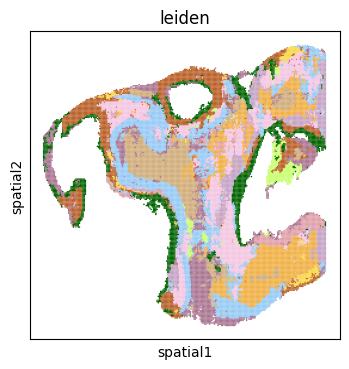

In [16]:
adata_sub = adata_final[adata_final.obs['slice_name']==slice_name_list[0]]
adata_sub.obs['leiden'] = adata_sub.obs['leiden'].astype(str).astype('category')
adata_sub.obs['leiden'] = adata_sub.obs['leiden'].cat.set_categories(all_clusters, ordered=True)
adata_sub.obsm['spatial'][:, 1] = -1*adata_sub.obsm['spatial'][:, 1]
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(adata_sub, basis="spatial",
                color="leiden",
                s=5,
                show=False, legend_loc=None,
                palette=plot_color)

/tmp/ipykernel_2530424/2732277410.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['leiden'] = adata_sub.obs['leiden'].astype(str).astype('category')
/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'leiden'}, xlabel='spatial1', ylabel='spatial2'>

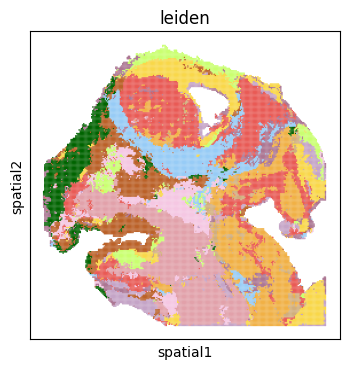

In [15]:
adata_sub = adata_final[adata_final.obs['slice_name']==slice_name_list[1]]
adata_sub.obs['leiden'] = adata_sub.obs['leiden'].astype(str).astype('category')
adata_sub.obs['leiden'] = adata_sub.obs['leiden'].cat.set_categories(all_clusters, ordered=True)
adata_sub.obsm['spatial'][:, 1] = -1*adata_sub.obsm['spatial'][:, 1]
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(adata_sub, basis="spatial",
                color="leiden",
                s=5,
                show=False, legend_loc=None,
                palette=plot_color)

/tmp/ipykernel_2530424/2077407316.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['leiden'] = adata_sub.obs['leiden'].astype(str).astype('category')
/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'leiden'}, xlabel='spatial1', ylabel='spatial2'>

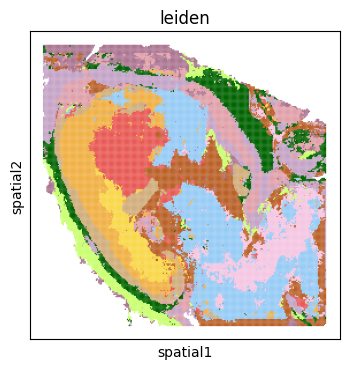

In [17]:
adata_sub = adata_final[adata_final.obs['slice_name']==slice_name_list[3]]
adata_sub.obs['leiden'] = adata_sub.obs['leiden'].astype(str).astype('category')
adata_sub.obs['leiden'] = adata_sub.obs['leiden'].cat.set_categories(all_clusters, ordered=True)
adata_sub.obsm['spatial'][:, 1] = -1*adata_sub.obsm['spatial'][:, 1]
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(adata_sub, basis="spatial",
                color="leiden",
                s=5,
                show=False, legend_loc=None,
                palette=plot_color)

/tmp/ipykernel_2530424/979820835.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_sub.obs['leiden'] = adata_sub.obs['leiden'].astype(str).astype('category')
/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


<Axes: title={'center': 'leiden'}, xlabel='spatial1', ylabel='spatial2'>

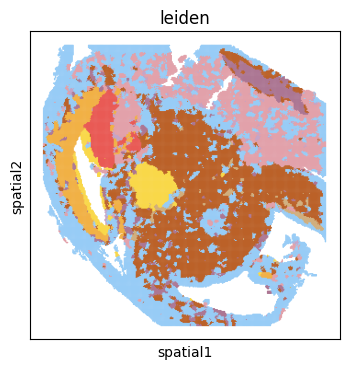

In [18]:
adata_sub = adata_final[adata_final.obs['slice_name']==slice_name_list[2]]
adata_sub.obs['leiden'] = adata_sub.obs['leiden'].astype(str).astype('category')
adata_sub.obs['leiden'] = adata_sub.obs['leiden'].cat.set_categories(all_clusters, ordered=True)
adata_sub.obsm['spatial'][:, 1] = -1*adata_sub.obsm['spatial'][:, 1]
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.embedding(adata_sub, basis="spatial",
                color="leiden",
                s=5,
                show=False, legend_loc=None,
                palette=plot_color)

/home/yuzhuohan/miniconda3/envs/SPHERE/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


(-10.257474422454834,
 21.263450145721436,
 -11.066412305831909,
 13.922566747665405)

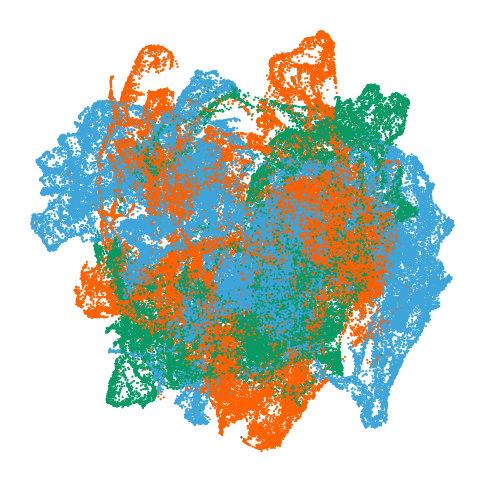

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import scanpy as sc

all_slices = list(adata_final.obs["slice_name"].cat.categories)
target_slices = [all_slices[0],all_slices[1],all_slices[3]] 
adata_plot = adata_final[adata_final.obs["slice_name"].isin(target_slices)].copy()

shuffled_indices = np.random.permutation(adata_plot.n_obs)
adata_plot = adata_plot[shuffled_indices].copy()

plot_color = ["#099963", "#FF6000", "#3DA5D9"]
plt.rcParams["figure.figsize"] = (6, 6)
fig, ax = plt.subplots()

sc.pl.umap(
    adata_plot, 
    color=["slice_name"],
    s=10,
    show=False,
    palette=plot_color[:3],  
    legend_loc=None,
    ax=ax
)

ax.set_title("")  
ax.set_xlabel("")  
ax.set_ylabel("")
ax.set_xticks([])  
ax.set_yticks([])  
ax.axis('off')  


(-10.257474422454834,
 21.263450145721436,
 -11.066412305831909,
 13.922566747665405)

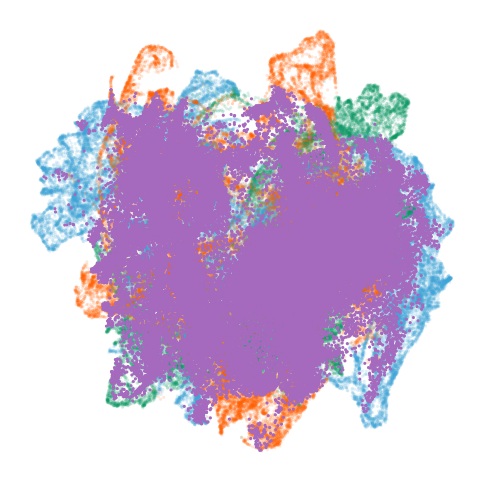

In [20]:
import matplotlib.pyplot as plt
import numpy as np

umap_coords = adata_final.obsm['X_umap']
slices = adata_final.obs['slice_name'].astype(str).values
slice_order = ['E11_0-S1', 'E18_5-S1', 'E13_5-S1', 'E15_5-S1']
color_map = {
    "E11_0-S1":      "#09996326",  
    "E18_5-S1": "#3DA5D926",
    "E13_5-S1":      "#FF600026", 
    "E15_5-S1":     "#A569BDFF",  
}

plt.rcParams["figure.figsize"] = (6, 6)
fig, ax = plt.subplots()

for s_name in slice_order:
    mask = (slices == s_name)
    ax.scatter(
        umap_coords[mask, 0], 
        umap_coords[mask, 1], 
        c=color_map[s_name], 
        s=5, 
        edgecolors='none',  
        label=s_name
    )

ax.set_title("")
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_xticks([])  
ax.set_yticks([]) 
ax.axis('off')     